# SHAP MAPS

In [6]:
future_dir = 'C:/Users/MPennino/OneDrive - Environmental Protection Agency (EPA)/Projects/OASES/Data/Future_NO3/'
model_dir = future_dir + "Models"
shap_dir = future_dir + "SHAP"

In [37]:
# States boundary file
import geopandas as gpd
states_path = 'D:/ArcGIS/Boundaries/States/conterminous_states_usgs/Conterminous_States_usgs.shp'
states = gpd.read_file(states_path)

In [ ]:
# Read in COMID centroids (1m 9s)
import geopandas as gpd
sp_dir = "D:/Data/Spatial/NHDPlusV2_Centroids/"

cats_centroids_path = sp_dir + "NHDPlusV2_Cat_All_centroid_point.shp"
cats_p = gpd.read_file(cats_centroids_path)

In [4]:
cats_p.columns

Index(['COMID', 'SOURCEFC', 'geometry'], dtype='str')

In [5]:
# Change projection (1s)
cats_p = cats_p.to_crs("EPSG:5070")


In [7]:
epsg_code = cats_p.crs.to_epsg()
print(epsg_code)

5070


In [ ]:
# # Import SHAP Values Dataset (only need the dataframe, not the SHAP values)

# import pickle
# import shap
# import torch

# #filename2 = '/torch_SHAP_Values_kfold_COMID_All_Observed_sw.pkl'
# filename2 = '/torch_SHAP_Values_model0_COMID_All_Observed_sw.pkl'

# with open(shap_dir + filename2, "rb") as f:
#     shap_values = pickle.load(f)

# type(shap_values)

c:\Users\MPennino\anaconda3\envs\shapmap_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


shap._explanation.Explanation

# Import SHAP DATA

In [122]:
# Import SHAP values DataFrame
import pandas as pd
#import pyarrow as pa
#import pyarrow.parquet as pq
dataset = "/torch_SHAP_Values_kfold_DF_COMID_All_Observed_sw.parquet"
#dataset = "/torch_SHAP_Values_model0_DF_COMID_All_Observed_sw.parquet"

#df_shap = pd.read_parquet(shap_dir+dataset) # Read a single Parquet file

import pyarrow.parquet as pq

df_shap = pq.read_table(shap_dir+dataset).to_pandas()
#df_shap.head()

# Most Positively Influential Variables

In [123]:
df_shap.columns

Index(['COMID', 'PopDen2010Ws', 'PctForest2019Ws', 'PctCrop2019Ws',
       'precip9120ws', 'tmean9120ws', 'BFIWs', 'permws', 'RockNWs',
       'N_TW2012Ws', 'N_Surp_kgsqkm_2017ws', 'ElevWs', 'Fe2O3Ws',
       'NHDslope_Pct_Ws'],
      dtype='str')

In [125]:
# Most Pos. influential variables
# Categories: temp, precip, N Surp, other N inputs (N Dep, Rock N), Land Use (crop, forest, popdens), soil/geology (Elev, perm, Fe203, slope, bfi)
maxshap = df_shap.copy()

# Find max shapley value in each row
maxshap['max_value'] = maxshap.drop('COMID', axis=1).max(axis=1)

# Find the variable name associated with the max value
maxshap['max_column'] = maxshap.drop('COMID', axis=1).idxmax(axis=1)

# Remove any rows that are negative
maxshap = maxshap[maxshap['max_value']>=0]

# Create Broader Categories
mapping = {
    'tmean9120ws':'Temperature', 'tmean9120cat':'Temperature',
    'precip9120ws':'Precipitation','precip9120cat':'Precipitation',
    'N_Surp_kgsqkm_2017ws':'N Surplus', 'N_Surp_kgsqkm_2017cat':'N Surplus',
    'RockNWs':'Other N Inputs','RockNCat':'Other N Inputs', 'N_TW2012Ws':'Other N Inputs','N_TW2012Cat':'Other N Inputs',
    'PopDen2010Ws':'Land Use','PopDen2010Cat':'Land Use', 'PctForest2019Ws':'Land Use','PctForest2019Cat':'Land Use','PctCrop2019Ws':'Land Use','PctCrop2019Cat':'Land Use',
    'BFIWs':'Environment', 'permws':'Environment','ElevWs':'Environment','Fe2O3Ws':'Environment','NHDslope_Pct_Ws':'Environment',
    'BFICat':'Environment', 'permcat':'Environment','ElevCat':'Environment','Fe2O3Cat':'Environment','NHDslope_Pct_Cat':'Environment'
}
maxshap['max_column2'] = maxshap['max_column'].map(mapping)                   

#maxshap.shape
#maxshap.head()
#has_nan = maxshap['max_column2'].isnull().any()
#print(has_nan)


In [126]:
# Most Neg. influential variables
# Categories: temp, precip, N Surp, other N inputs (N Dep, Rock N), Land Use (crop, forest, popdens), soil/geology (Elev, perm, Fe203, slope, bfi)
minshap = df_shap.copy()

# Find min shapley value in each row
minshap['min_value'] = minshap.drop('COMID', axis=1).min(axis=1)

# Find the variable name associated with the min value
minshap['min_column'] = minshap.drop('COMID', axis=1).idxmin(axis=1)

# Remove any rows that are positive
minshap = minshap[minshap['min_value']<=0]

# Create Broader Categories
mapping = {
    'tmean9120ws':'Temperature', 'tmean9120cat':'Temperature',
    'precip9120ws':'Precipitation','precip9120cat':'Precipitation',
    'N_Surp_kgsqkm_2017ws':'N Surplus', 'N_Surp_kgsqkm_2017cat':'N Surplus',
    'RockNWs':'Other N Inputs','RockNCat':'Other N Inputs', 'N_TW2012Ws':'Other N Inputs','N_TW2012Cat':'Other N Inputs',
    'PopDen2010Ws':'Land Use','PopDen2010Cat':'Land Use', 'PctForest2019Ws':'Land Use','PctForest2019Cat':'Land Use','PctCrop2019Ws':'Land Use','PctCrop2019Cat':'Land Use',
    'BFIWs':'Environment', 'permws':'Environment','ElevWs':'Environment','Fe2O3Ws':'Environment','NHDslope_Pct_Ws':'Environment',
    'BFICat':'Environment', 'permcat':'Environment','ElevCat':'Environment','Fe2O3Cat':'Environment','NHDslope_Pct_Cat':'Environment'
}
minshap['min_column2'] = minshap['min_column'].map(mapping)     

In [127]:
# Merge shap results with Shapefile
shap_max = cats_p.merge(maxshap, on="COMID", how="left")
shap_min = cats_p.merge(minshap, on="COMID", how="left")


epsg_code1 = shap_max.crs.to_epsg()
print(epsg_code1)


5070


In [128]:
# remove NA rows
shap_max = shap_max.dropna(subset=['max_column'])
shap_min = shap_min.dropna(subset=['min_column'])

shap_max.shape, shap_min.shape


((14934, 19), (14934, 19))

# Generate Maps

In [129]:
import plotly.express as px
from matplotlib.colors import ListedColormap

# Slice the first 6 categories from a built-in palette
colors_plotly = px.colors.qualitative.Plotly[:6]
colors_plotly2 = ListedColormap(colors_plotly) # Convert the list into a Matplotlib colormap object

print(colors_plotly)

['#636EFA', '#EF553B', '#00CC96', '#AB63FA', '#FFA15A', '#19D3F3']


In [130]:
import seaborn as sns

# Generate a list of 6 distinct colorblind-friendly colors
colors_sns = sns.color_palette("colorblind", 6)

# Generate a list as hex strings
colors_hex = sns.color_palette("colorblind", 6).as_hex()
colors_hex2 = ListedColormap(colors_hex) # Convert the list into a Matplotlib colormap object

print(colors_hex)

['#0173b2', '#de8f05', '#029e73', '#d55e00', '#cc78bc', '#ca9161']


In [131]:
# Generage subset for testing
#test_s = shap_s.sample(n=200)

In [132]:
epsg_code1 = shap_max.crs.to_epsg()
epsg_code2 = states.crs.to_epsg()

print(epsg_code1)
print(epsg_code2)

5070
5070


In [133]:
# Get unique values as a NumPy array
unique_array = shap_max['max_column2'].unique()
print(unique_array)

<ArrowStringArray>
['Other N Inputs',       'Land Use',    'Environment',  'Precipitation',
      'N Surplus',    'Temperature']
Length: 6, dtype: str


In [134]:
mycolors = ListedColormap(['grey','yellow','red','orange','blue','purple']) # Convert the list into a Matplotlib colormap object


c:\Users\MPennino\anaconda3\envs\shapmap_env\Lib\site-packages\geopandas\plotting.py:305: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  collection = ax.scatter(x, y, vmin=vmin, vmax=vmax, cmap=cmap, **kwargs)


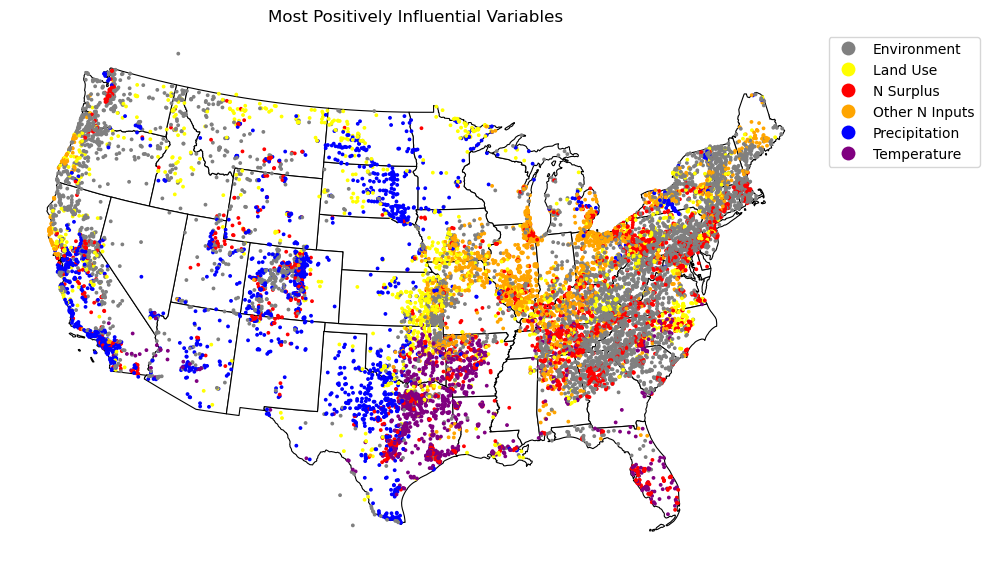

In [135]:
# MAPING Max Shap Variable
# This maps state boundaries on bottom
import geopandas as gpd
import matplotlib.pyplot as plt

points = shap_max

# CRITICAL: Ensure both datasets share the exact same Coordinate Reference System (CRS)
if points.crs != states.crs:
    points = points.to_crs(states.crs)

# 2. Create a single figure and axis object
fig, ax = plt.subplots(figsize=(10, 10))

# 3. Plot the states boundaries FIRST (as the background)
states.plot(
    ax=ax, 
    color='white',      # Fill color of the states
    edgecolor='black',  # Boundary line color
    linewidth=0.8
)

# 4. Plot the points SECOND (layered on top)
points.plot(
    ax=ax,              # Draws it on the exact same axis as the states
    column='max_column2',  
    categorical=True,               
    legend=True,                    
    marker='o',  
    facecolors='none', # for open circles                   
    markersize=3,                  
    cmap=mycolors, #colors_plotly2, # 'Set1',
    legend_kwds={'loc': 'upper left', 'bbox_to_anchor': (1, 1)} # Moves legend outside map boundary
)

# Remove the outside axis, ticks, and frame completely
ax.set_axis_off()
plt.title("Most Positively Influential Variables")
plt.tight_layout()
plt.show()

c:\Users\MPennino\anaconda3\envs\shapmap_env\Lib\site-packages\geopandas\plotting.py:305: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  collection = ax.scatter(x, y, vmin=vmin, vmax=vmax, cmap=cmap, **kwargs)


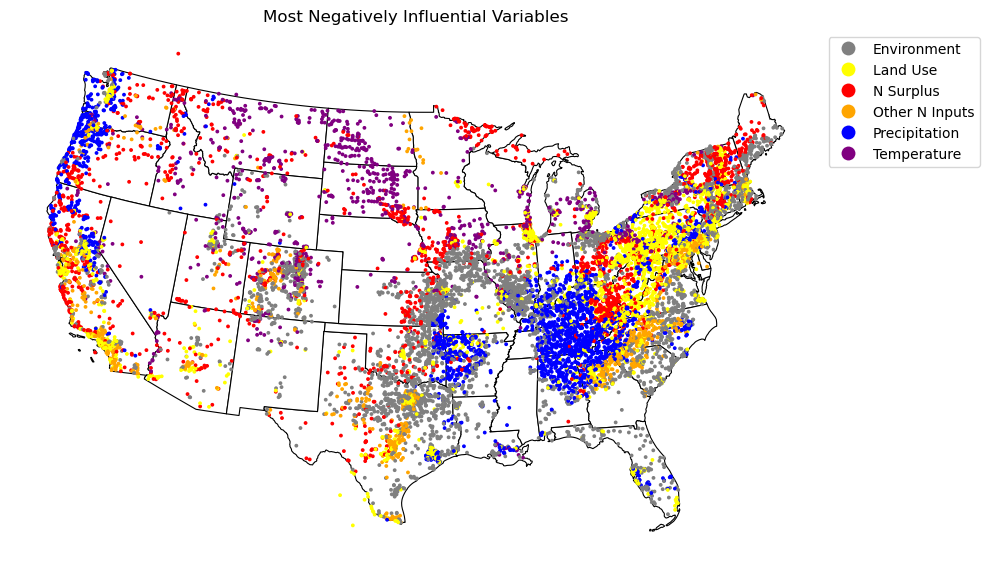

In [136]:
# MAPING Min Shap Variable
# This maps state boundaries on bottom
import geopandas as gpd
import matplotlib.pyplot as plt

points = shap_min

# CRITICAL: Ensure both datasets share the exact same Coordinate Reference System (CRS)
if points.crs != states.crs:
    points = points.to_crs(states.crs)

# 2. Create a single figure and axis object
fig, ax = plt.subplots(figsize=(10, 10))

# 3. Plot the states boundaries FIRST (as the background)
states.plot(
    ax=ax, 
    color='white',      # Fill color of the states
    edgecolor='black',  # Boundary line color
    linewidth=0.8
)

# 4. Plot the points SECOND (layered on top)
points.plot(
    ax=ax,              # Draws it on the exact same axis as the states
    column='min_column2',  
    categorical=True,               
    legend=True,                    
    marker='o',  
    facecolors='none', # for open circles                   
    markersize=3,                  
    cmap=mycolors, #colors_plotly2, # 'Set1',
    legend_kwds={'loc': 'upper left', 'bbox_to_anchor': (1, 1)} # Moves legend outside map boundary
)

# Remove the outside axis, ticks, and frame completely
ax.set_axis_off()
plt.title("Most Negatively Influential Variables")
plt.tight_layout()
plt.show()